In [1]:
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
import pandas            as pd
import json
import os

from pymatgen.core.structure import Structure

sns.set_theme()

We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name to reference folder which stores the energies of each slab
slab_folder = 'input/BiSeI/slab_v0'

Surface formation energy of shape $S$ for slab of energy $E_S$ with $N$ formula units and $E_{bulk}$ bulk energy is:

\begin{equation}
    E_S = \frac{E_S - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [3]:
bulk_folder = f'{slab_folder}/bulk'

# Load the bulk energy
bulk_energy = np.loadtxt(f'{bulk_folder}/single_shot_energy')

# Load the data from the JSON file
with open(f'{bulk_folder}/slab_data.json', 'r') as json_file:
    slab_data = json.load(json_file)

bulk_energy_per_atom = bulk_energy / slab_data['number_of_sites']

In [4]:
# Initialize the data dictionary for storing all slab energy calculations
slab_energies = {}

# Iterate over slabs
for miller_index_str in os.listdir(slab_folder):
    # Define current folder
    current_folder = f'{slab_folder}/{miller_index_str}'

    # Skip in case it is not a folder or it is the bulk folder
    if (not os.path.isdir(current_folder)) or (miller_index_str == 'bulk'):
        continue

    # Load the data from the JSON file
    with open(f'{current_folder}/slab_data.json', 'r') as json_file:
        slab_data = json.load(json_file)

    print()
    print('Miller index:', slab_data['miller_index'])
    print('Shift:', slab_data['shift'])
    print('Surface area:', slab_data['surface_area'])
    print('Number of sites:', slab_data['number_of_sites'])

    # Load the single-shot energy
    ssc_energy = np.loadtxt(f'{current_folder}/single_shot_energy')

    # Get energy per atom
    ssc_energy_per_atom = ssc_energy / slab_data['number_of_sites']
    
    # Compute slab energy in eV/atom/ang^2
    slab_energy = (ssc_energy_per_atom - bulk_energy_per_atom) / (2 * slab_data['surface_area'])

    # Load the slab energy
    np.savetxt(f'{current_folder}/slab_energy', [slab_energy])

    print(f'\t{slab_energy} eV/atom/Å^2')

    # Generate a dictionary object with the new data and update in the main data object
    slab_energies.update({
        (miller_index_str): slab_energy
    })

# Convert to Pandas DataFrame
slab_energies = pd.DataFrame(slab_energies, index=['energy'])


Miller index: [1, 1, 2]
Shift: 0.9999999999999893
Surface area: 121.76632531428685
Number of sites: 84
	0.0002074728646703226 eV/atom/Å^2

Miller index: [1, 1, 2]
Shift: 0.4469720005425053
Surface area: 121.76632531428685
Number of sites: 84
	0.0003141892680123343 eV/atom/Å^2

Miller index: [1, 0, 2]
Shift: 0.25
Surface area: 113.79691876782465
Number of sites: 84
	0.0002219826925200891 eV/atom/Å^2

Miller index: [1, 0, 2]
Shift: 0.11623357258945788
Surface area: 113.79691876782465
Number of sites: 84
	0.0002637509169110565 eV/atom/Å^2

Miller index: [0, 0, 1]
Shift: 0.25000000000000355
Surface area: 35.826380355693765
Number of sites: 24
	0.0003698095472794363 eV/atom/Å^2

Miller index: [1, 0, 1]
Shift: 0.19188321370528527
Surface area: 95.3894655236015
Number of sites: 72
	0.00036940385311617647 eV/atom/Å^2

Miller index: [1, 0, 2]
Shift: 0.04065429517257968
Surface area: 113.79691876782465
Number of sites: 84
	0.00030814704742009345 eV/atom/Å^2

Miller index: [1, 1, 2]
Shift: 0.304

# Extract local minimas and generate input files

In [5]:
# Sorted in ascendent order
min_arg       = np.argsort(slab_energies.values)[0]
local_minimas = slab_energies.columns[min_arg]
energies      = slab_energies.values[0][min_arg]

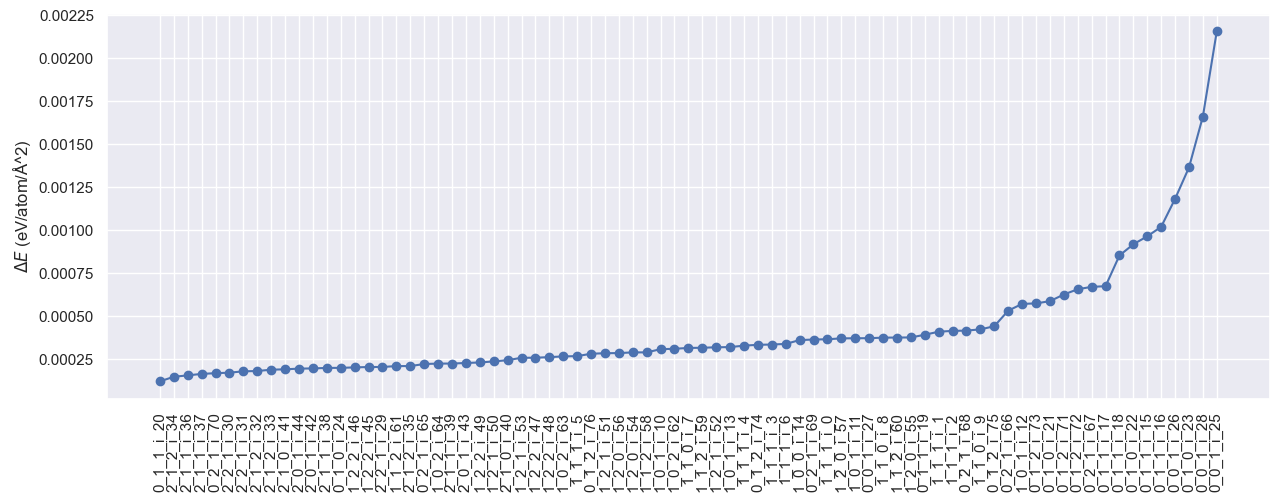

In [6]:
# Energy differences in eV/supercell
plt.figure(figsize=(15, 5))
plt.plot(energies, 'o-')
plt.xticks(range(len(local_minimas)), local_minimas, rotation='vertical')
plt.ylabel(r'$\Delta E$ (eV/atom/Å^2)')
plt.savefig(f'{slab_folder}/ranking.eps', dpi=50, bbox_inches='tight')
plt.show()